# BrushCue Example: Liquify

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/liquify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/liquify

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver '

'


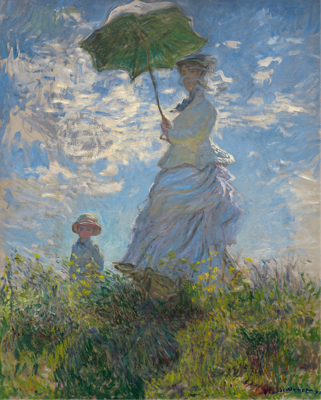

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
graph = input_image.liquify(15.45, 0.017).crop(
    bc.Bounds2f.from_x_y_width_height(
        (input_image.bounds().min_x() + 15.45),
        (input_image.bounds().min_y() + 15.45),
        (input_image.bounds().width() - (15.45 * 2.0)),
        (input_image.bounds().height() - (15.45 * 2.0)),
    )
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
